# Método de Excedentes Fraccionarios Monocromático (MEFM)
---

Para adaptar el método de fracciones exactas descrito por T. Liu (1) al uso de una única longitud de onda debe tenerse un conocimiento previo del bloque patrón. Esto debido a que al utilizar una sola longitud de onda, la distancia ente cada posible valor valido para longitud real ($L_{real}$) es exactamente de $\lambda / 2$. En el caso de utilizar luz dentro del espectro visible, esto significa que las soluciones están separadas por unos 250 a 350 nanómetros.

Para seleccionar el valor "correcto" de $L_{real}$ a partir de una única longitud de onda se requiere que de la medición mecánica prelminar, que resulta en la longitud nominal ($L'$), tenga una incertidumbre total combinada estrictamente menor a $\pm \lambda / 4$. Si está incertudumbre es tan pequeña, el intervalo aceptable de error se reduce drasticamente. Matemáticamete, solo uno de los posibles valores generados por el método caerá dentro de esta estrecha franja de incertidumbre. En este escenario, una segunda o más longitudes de onda no son necesarias para confirmar la longitud obtenida, el único valor que entra en el rango es la solución "correcta".

In [101]:
%load_ext autoreload
%autoreload 2

import sys
import os
# Agrega el directorio padre (la raíz del repositorio) al path temporal de Python
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import matplotlib.pyplot as plt

from src.mefm_solver import MonochromaticEFMSolver

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [102]:
# incoming data
nominal_length = 10e6 # [nm]
delta_nominal_length = -150 # [nm]
uncertainty = 36.0 # [nm] U =(0.03 + 6*10^-4 * L mm)

# real length
fractional_real = 0.573

lambda_ = 632.9912 # [nm]

La relación entre $L_{real}$ y la longitud de onda de medida está dada por:

\begin{equation}
    L_{real} = (N_{real} + \epsilon_{real}) \frac{\lambda}{2},
\end{equation}

donde $N_{real}$ es la parte entera desconocida del orden de franja para la longitud de onda $\lambda$, $\epsilon_{real}$ es el valor de fraccional de franja previamente medido, cuyo valor está en el intervalo $[0, 1]$. Analogamente, la longitud de onda nominal puede expresarse como:

\begin{equation}
    L' = (N' + \epsilon') \frac{\lambda}{2},
\end{equation}

Para obtener la parte entera de la franja de interferencia $N_{real}$, es necesario primero obtener el valor de la parte fraccionaria correspondiente a la longitud nominal, es decir, $\epsilon'$:

\begin{equation}
    \epsilon' = \frac{2L'}{\lambda} - INT\bigg(\frac{2L'}{\lambda}\bigg),
\end{equation}

donde $INT(\cdot)$ es la función para obtener la parte entera.

In [103]:
fractional_prime, integral_prime = np.modf((2 * nominal_length) / lambda_)
print(f"Total: {2 * nominal_length / lambda_}")
print(f"Integral part: {integral_prime}")
print(f"Fractional part: {fractional_prime}")

Total: 31596.015868783008
Integral part: 31596.0
Fractional part: 0.015868783008045284


En lugar de intentar calcular directamente la parte entera fraccionaria, transformamos el problema a la determinación de la diferencia $c$ entre la parte nominal $L'$ y la parte entera $L_{entera}$, es decir, $c = L_{real} - L'$, luego:

\begin{equation}
    c = L_{real} - L' = (m + \delta)\frac{\lambda}{2}
\end{equation}

en donde $m\frac{\lambda}{2} = (N_{real} - N')\frac{\lambda}{2}$ es la parte entera de $c$ y $\delta\frac{\lambda}{2} = (\epsilon_{real} - \epsilon')\frac{\lambda}{2}$ es la parte fraccionaria de $c$ y ya está determinado por las condiciones expuestas. El problema se ha trasladado de deteminar la parte entera del orden de franja $N_{real}$ a determinar el valor de $c$. El máximo valor de desajuste permitido para $N'$ es:

\begin{equation}
    \Delta N' = INT \bigg(\frac{2\Delta L'_{error}}{\lambda}\bigg),
\end{equation}

en donde $\Delta L'_{error}$ es el rango de error de la longitud nominal. Luego, el valor de $m_j$ para la parte entera de $c$ se encuentra en el intervalo:

\begin{equation}
   -\Delta N' \leq m_j \leq \Delta N'
\end{equation}

Por tanto, el valor para la diferencia $c$ puede ser ajustado por la variable m_j como:

\begin{equation}
    c_j = (m_j + \delta) \frac{\lambda}{2}.
\end{equation}

El valor obtenido para c_j se compara con el intervalo deteminado por:

\begin{equation}
    [-L'_{error}, L'_{error}]
\end{equation}

In [104]:
# m_j = np.linspace(-int(2 * (delta_nominal_length + uncertainty) / lambda_), int(2 * (delta_nominal_length + uncertainty) / lambda_), num=10)
m_j = np.linspace(-3, 3, num=7)
print(f"m_j values: {m_j}")
difference = (lambda_ / 2) * (m_j + fractional_real - fractional_prime)
print(f"Difference: {difference}")

# acceptance interval
c = 0.0
lower_bound = delta_nominal_length - uncertainty
upper_bound = delta_nominal_length + uncertainty
for i in difference:
    if i > lower_bound and i < upper_bound:
       c = i
print(f"Lower bound: {lower_bound} nm")
print(f"Upper bound: {upper_bound} nm")
print(f"c difference value: {c}") 
    

m_j values: [-3. -2. -1.  0.  1.  2.  3.]
Difference: [-773.1572212 -456.6616212 -140.1660212  176.3295788  492.8251788
  809.3207788 1125.8163788]
Lower bound: -186.0 nm
Upper bound: -114.0 nm
c difference value: -140.16602119940111


Finalmente, con el valor de c_j encontrado y verificado en el intervalo de aceptancia, la longitud real del bloque puede calcularse como:

\begin{equation}
    L_{real} = L' + C_j
\end{equation}

Nota: La longitud, aunque se denota acá como longitud real, aún no esta calculada con las correcciones correspondientes.

In [105]:
L_real = nominal_length + c
print(f"Real length: {L_real} nm")

Real length: 9999859.8339788 nm


## Referencias

[1] T. Liu, J. Wu, R. Sato, H. Matsukuma, and W. Gao, Theoretical Analysis on Gauge Block Length Measurement by Excess Fraction Method, in 2022 8th International Conference on Nanomanufacturing & 4th AET Symposium on ACSM and Digital Manufacturing (Nanoman-AETS) (2022), pp. 1–7.

---
## Test del código empaquetado

In [106]:
he_ne_laser = MonochromaticEFMSolver(wavelength=632.9912)

# Evaluate the 10 mm block with the mechanical and optical data
try:
    result = he_ne_laser.evaluate_block(
        nominal_length=10e6,           
        delta_nominal_length=-150.0,   
        uncertainty=36.0,              
        measured_fraction=0.573        
    )
        
    print("Calibration Results:")
    print("-" * 20)
    print(f"Real Length:        {result['real_length_nm']:.3f} nm")
    print(f"Accepted c_j value: {result['c_difference_nm']} nm")
    print(f"Acceptance bounds:  {result['acceptance_interval']}")

except ValueError as e:
    print(f"Method Error: {e}")
except RuntimeError as e:
    print(f"Logic Error: {e}")

Calibration Results:
--------------------
Real Length:        9999859.834 nm
Accepted c_j value: -140.16602119940111 nm
Acceptance bounds:  (-186.0, -114.0)


---
### Ejemplo 2

In [107]:
he_ne_laser = MonochromaticEFMSolver(wavelength=543.5)

# Evaluate the 100 mm block with the mechanical and optical data
try:
    result = he_ne_laser.evaluate_block(
        nominal_length=100e6,           
        delta_nominal_length=-60.0,  # Tomado de certificado
        uncertainty=90.0,            # (0.03 + (6e-4)*100)*1e3 # nm | Tomado de certificado  
        measured_fraction=0.3908     # valor obtenido por el script para bloque de 100.0 mm
    )
        
    print("Calibration Results:")
    print("-" * 20)
    print(f"Real Length:        {result['real_length_nm']:.3f} nm")
    print(f"Accepted c_j value: {result['c_difference_nm']} nm")
    print(f"Acceptance bounds:  {result['acceptance_interval']}")

except ValueError as e:
    print(f"Method Error: {e}")
except RuntimeError as e:
    print(f"Logic Error: {e}")

Calibration Results:
--------------------
Real Length:        100000029.950 nm
Accepted c_j value: 29.94989999828287 nm
Acceptance bounds:  (-150.0, 30.0)


In [108]:
result['real_length_nm']*1e-6

np.float64(100.0000299499)

---
# Profundización del método: Casos de validación

### Block nominal length: 100 mm

In [109]:
from dataclasses import dataclass
from typing import Dict

@dataclass
class GaugeBlock:
    nominal_length_mm: float
    deviation_nm: float

    @property
    def nominal_length_nm(self) -> float:
        """Convert nominal length from mm to nm."""
        return self.nominal_length_mm * 1e6

    @property
    def uncertainty_nm(self) -> float:
        """Calculate calibration uncertainty in nm based on the certificate formula."""
        # Formula: (0.03 + 6e-4 * L_mm) * 1e3
        return (0.03 + (6e-4) * self.nominal_length_mm) * 1e3

@dataclass
class Laser:
    wavelength: float                           # [nm]
    uncertainty: float                          # [nm]
    measured_fractions: Dict[str, float]
    
    

In [110]:
# def compute_lengths_for_several_wavelength(wavelength, wavelength_uncertainty, 
#                                            nominal_length, delta_nominal_length, length_uncertainty,
#                                            measured_fraction,
#                                            n_points: int = 100) -> tuple:
#     upper_limit = wavelength + wavelength_uncertainty
#     lower_limit = wavelength - wavelength_uncertainty
#     wavelengths = np.linspace(lower_limit, upper_limit, n_points)
    
#     lengths = []
#     wavelengths_pass = [] 

#     for i, wl in enumerate(wavelengths):
#         try:
#             he_ne_laser = MonochromaticEFMSolver(wavelength=wl)
#             result = he_ne_laser.evaluate_block(
#                 nominal_length=nominal_length,           
#                 delta_nominal_length=delta_nominal_length,              
#                 uncertainty=length_uncertainty,              
#                 measured_fraction=measured_fraction    # valor obtenido por el script para bloque de 100.0 mm
#             )
#             # print(i)
#             lengths.append(result['real_length_nm'])
#             wavelengths_pass.append(wl)
#         except ValueError as e:
#             print(f"Method Error: {e}")
#         except RuntimeError as e:
#             print(f"Logic Error: {e}")
#             # print(f"Here {i}")
#             # lengths.append(0.9e8)
#     return (wavelengths_pass, lengths)

import numpy as np
from typing import Tuple, List

def compute_lengths_for_several_wavelengths(
    laser: Laser, 
    gauge_block: GaugeBlock, 
    measured_fraction: float, 
    n_points: int = 100
) -> Tuple[List[float], List[float]]:
    """
    Computes the real lengths for a range of wavelengths within the laser's uncertainty bounds.
    """
    upper_limit = laser.wavelength + laser.uncertainty
    lower_limit = laser.wavelength - laser.uncertainty
    
    # Generate an array of wavelengths to test
    wavelengths = np.linspace(lower_limit, upper_limit, n_points)
    
    lengths = []
    valid_wavelengths = [] 

    for wl in wavelengths:
        try:
            # Initialize solver with the current test wavelength
            solver = MonochromaticEFMSolver(wavelength=wl)
            
            # Evaluate using the properties directly from the GaugeBlock dataclass
            result = solver.evaluate_block(
                nominal_length=gauge_block.nominal_length_nm,          
                delta_nominal_length=gauge_block.deviation_nm,              
                uncertainty=gauge_block.uncertainty_nm,              
                measured_fraction=measured_fraction
            )
            
            lengths.append(result['real_length_nm'])
            valid_wavelengths.append(wl)
            
        except ValueError as e:
            print(f"Method Error at wavelength {wl}: {e}")
        except RuntimeError as e:
            print(f"Logic Error at wavelength {wl}: {e}")
            
    return valid_wavelengths, lengths
# )

In [111]:
# Initialize the laser objects
red_laser = Laser(
    wavelength=632.9905846,
    uncertainty=0.00000006,
    measured_fractions={
        "100_mm": 0.9661,
        "10_mm": 0.0465
    }
)

green_laser = Laser(
    wavelength=543.5,
    uncertainty=0.00073848,
    measured_fractions={
        "100_mm": 0.2806,
        "10_mm": 0.0276
    }
)

system_lasers = {
    "red": red_laser,
    "green": green_laser
}

# # Initialize the laser objects
# red_laser = Laser(
#     wavelength=632.9912,
#     uncertainty=0.00000006,
#     measured_fractions={
#         "100_mm": 0.9661,
#         "10_mm": 0.5730
#     }
# )

# green_laser = Laser(
#     wavelength=543.5,
#     uncertainty=0.00073848,
#     measured_fractions={
#         "100_mm": 0.2806,
#         "10_mm": 0.0276
#     }
# )

# system_lasers = {
#     "red": red_laser,
#     "green": green_laser
# }

In [112]:
# Instance gauge blocks
block_10mm = GaugeBlock(
    nominal_length_mm=10.0, 
    deviation_nm=-150.0
)

block_100mm = GaugeBlock(
    nominal_length_mm=100.0, 
    deviation_nm=-60.0
)

gauge_blocks = {
    "10_mm": block_10mm,
    "100_mm": block_100mm
}

In [135]:
# calibration results for the four cases
def compute_excess_fraction(
    wl,
    laser: Laser, 
    gauge_block: GaugeBlock,
    length
    ):
    print("--"*10)
    print(wl)
    print(laser.measured_fractions[length])
    print(gauge_block.nominal_length_nm)
    print(gauge_block.deviation_nm)
    print(gauge_block.uncertainty_nm)
    
    try:
        # Initialize solver with the current test wavelength
        solver = MonochromaticEFMSolver(wavelength=wl)
            
        # Evaluate using the properties directly from the GaugeBlock dataclass
        result = solver.evaluate_block(
            nominal_length=gauge_block.nominal_length_nm,          
            delta_nominal_length=gauge_block.deviation_nm,              
            uncertainty=gauge_block.uncertainty_nm,              
            measured_fraction=laser.measured_fractions[length]
        )

            
        # lengths.append(result['real_length_nm'])
        # valid_wavelengths.append(wl)
        return result['real_length_nm']
            
    except ValueError as e:
        print(f"Method Error at wavelength {wl}: {e}")
    except RuntimeError as e:
        print(f"Logic Error at wavelength {wl}: {e}")
        

In [136]:
print(red_laser.wavelength)
print(red_laser.measured_fractions["10_mm"])
print(gauge_blocks["10_mm"])

compute_excess_fraction(
    wl=red_laser.wavelength,
    laser=system_lasers["red"], 
    gauge_block=gauge_blocks["10_mm"],
    length="10_mm"
    )

632.9905846
0.0465
GaugeBlock(nominal_length_mm=10.0, deviation_nm=-150.0)
--------------------
632.9905846
0.0465
10000000.0
-150.0
36.0
Logic Error at wavelength 632.9905846: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is -0.03 nm. Allowed bounds: (-186.00, -114.00). Tolerance missed by 113.97 nm.


In [115]:
compute_excess_fraction(
    wl=red_laser.wavelength,
    laser=system_lasers["red"], 
    gauge_block=gauge_blocks["100_mm"],
    length="100_mm"
    )

Logic Error at wavelength 632.9905846: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is -158.17 nm. Allowed bounds: (-150.00, 30.00). Tolerance missed by 8.17 nm.


In [116]:
compute_excess_fraction(
    wl=green_laser.wavelength,
    laser=system_lasers["green"], 
    gauge_block=gauge_blocks["100_mm"],
    length="100_mm"
    )

100000000.0
-60.0
90.0
0.2806


np.float64(100000000.00305)

In [117]:
compute_excess_fraction(
    wl=green_laser.wavelength,
    laser=system_lasers["green"], 
    gauge_block=gauge_blocks["10_mm"],
    length="10_mm"
    )

10000000.0
-150.0
36.0
0.0276


np.float64(9999864.0003)

In [118]:
compute_excess_fraction(
    wl=green_laser.wavelength,
    laser=system_lasers["green"], 
    gauge_block=gauge_blocks["10_mm"],
    length="10_mm"
    )

10000000.0
-150.0
36.0
0.0276


np.float64(9999864.0003)

In [119]:
# Red laser -> Gauge block: 100.0 mm
wls_red_100mm, lengths__red_100mm = compute_lengths_for_several_wavelengths(
    laser=system_lasers["red"],
    gauge_block=gauge_blocks["100_mm"],
    measured_fraction=system_lasers["red"].measured_fractions["100_mm"], n_points=5000
)

# Red laser -> Gauge block: 10.0 mm
wls_red_10mm, lengths_red_10mm = compute_lengths_for_several_wavelengths(
    laser=system_lasers["red"],
    gauge_block=gauge_blocks["10_mm"],
    measured_fraction=system_lasers["red"].measured_fractions["10_mm"], n_points=1000
)

Logic Error at wavelength 632.99058454: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is -158.18 nm. Allowed bounds: (-150.00, 30.00). Tolerance missed by 8.18 nm.
Logic Error at wavelength 632.990584540024: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is -158.18 nm. Allowed bounds: (-150.00, 30.00). Tolerance missed by 8.18 nm.
Logic Error at wavelength 632.990584540048: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is -158.18 nm. Allowed bounds: (-150.00, 30.00). Tolerance missed by 8.18 nm.
Logic Error at wavelength 632.990584540072: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is -158.18 nm. Allowed bounds: (-150.00, 30.00). Tolerance missed by 8.18 nm.
Logic Error at wavelength 632.990584540096: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is -158.18 nm. Allowed

In [120]:
wls_red_100mm

[]

In [121]:
# Green laser -> Gauge block: 100.0 mm
wls_green_100mm, lengths__green_100mm = compute_lengths_for_several_wavelengths(
    laser=system_lasers["green"],
    gauge_block=gauge_blocks["100_mm"],
    measured_fraction=system_lasers["green"].measured_fractions["100_mm"]
)

# Green laser -> Gauge block: 10.0 mm
wls_green_10mm, lengths_green_10mm = compute_lengths_for_several_wavelengths(
    laser=system_lasers["green"],
    gauge_block=gauge_blocks["10_mm"],
    measured_fraction=system_lasers["green"].measured_fractions["10_mm"]
)

Logic Error at wavelength 543.5001715660607: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is 31.57 nm. Allowed bounds: (-150.00, 30.00). Tolerance missed by 1.57 nm.
Logic Error at wavelength 543.5001864848484: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is 34.31 nm. Allowed bounds: (-150.00, 30.00). Tolerance missed by 4.31 nm.
Logic Error at wavelength 543.5002014036363: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is 37.06 nm. Allowed bounds: (-150.00, 30.00). Tolerance missed by 7.06 nm.
Logic Error at wavelength 543.5002163224242: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is 39.80 nm. Allowed bounds: (-150.00, 30.00). Tolerance missed by 9.80 nm.
Logic Error at wavelength 543.5002312412121: Convergence failure: No optical value matches the mechanical measurement. Closest c_value is 42.55 nm. Allowed 

In [122]:
def plot_length_vs_wavelength(
    wavelengths: list, 
    lengths: list, 
    original_wavelength: float, 
    block_name: str, 
    laser_color: str = "k"
) -> None:
    """
    Plots the calculated gauge block length against the swept wavelengths.
    """
    fig, ax = plt.subplots(figsize=(15, 5))
    
    # Convert lengths from nm to micrometers
    lengths_um = np.array(lengths) * 1e-3
    
    ax.scatter(wavelengths, lengths_um, color=laser_color, linewidth=1.0, label="Computed Lengths")
    
    # Plot the original nominal wavelength
    ax.axvline(
        original_wavelength, 
        color='green', 
        linestyle='--', 
        alpha=0.7, 
        label=rf'Original $\lambda$ = {original_wavelength} nm'
    )

    ax.set_title(f"Calculated Length vs Wavelength | Gauge Block: {block_name}", fontsize=12)
    ax.set_xlabel("Wavelength [nm]", fontsize=10)
    ax.set_ylabel(r"Length [$\mu m$]", fontsize=10)

    # Disable offset and scientific notation for exact visualization
    ax.get_yaxis().get_major_formatter().set_useOffset(False)
    ax.get_yaxis().get_major_formatter().set_scientific(False)
    ax.get_xaxis().get_major_formatter().set_useOffset(False)
    ax.get_xaxis().get_major_formatter().set_scientific(False)

    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend()

    plt.tight_layout()
    plt.show()

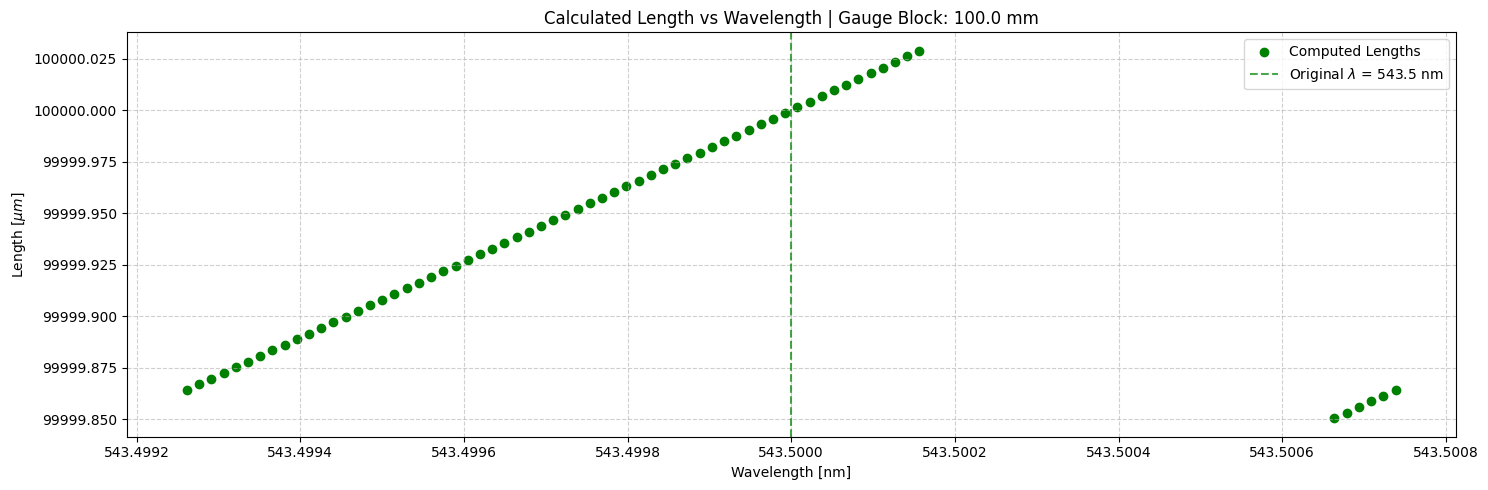

In [123]:
plot_length_vs_wavelength(
    wavelengths=wls_green_100mm,
    lengths= lengths__green_100mm,
    original_wavelength=system_lasers["green"].wavelength,
    block_name="100.0 mm",
    laser_color="green"
)


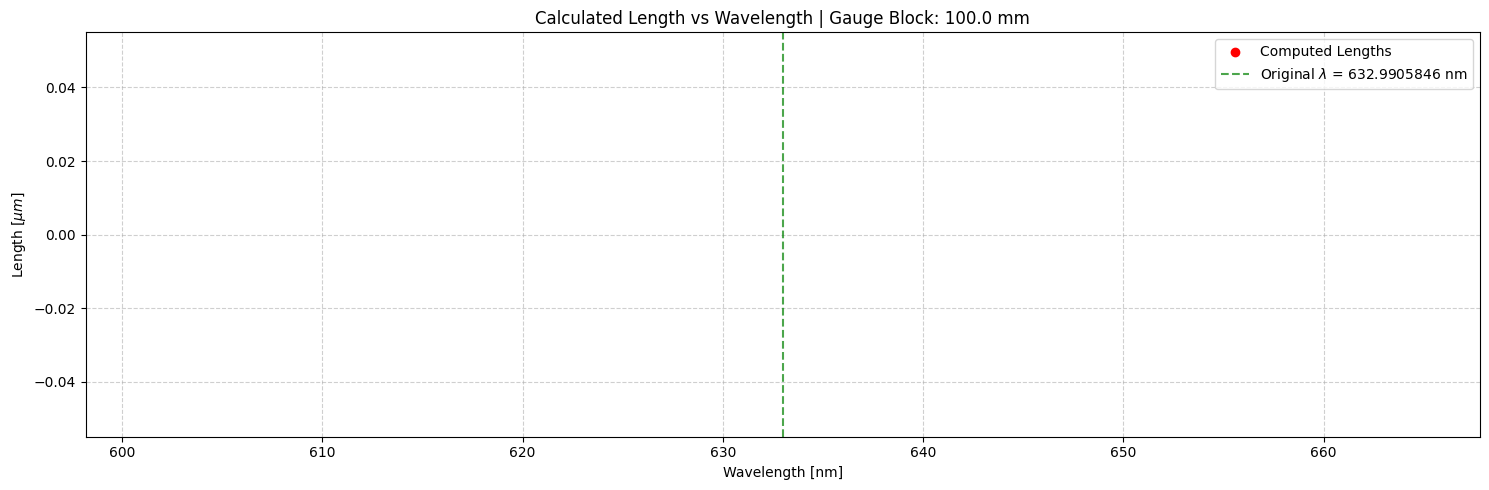

In [124]:
plot_length_vs_wavelength(
    wavelengths=wls_red_100mm,
    lengths= lengths__red_100mm,
    original_wavelength=system_lasers["red"].wavelength,
    block_name="100.0 mm",
    laser_color="red"
)

El comportamiento periodico observado (en la dependencia de la longitud del bloque patrón respecto a la longitud de onda) es un reflejo directo del comportamiento de la fase interferométrica, lo cual permite entender las limitaciones del Método de Excedentes Fracionarios Monocromatico frente a inestabilidades experimentales.

Físicamente, la ecuación fundamental $L = (N +\epsilon)\frac{\lambda}{2}$ incorpora una alta sensibidad a los valores de $\lambda$. Cuando se calcula la fracción teórica de la longitud nominal, se hace tomando la parte decimal de un número muy grade (orden de franja). A medida que se varian los valores de $\lambda$, el cociente $\frac{2L'}{\lambda}$ no cambia de forma suave y continua, sino que su parte fraccionaria describe una onda periódica de diente de sierra. Dado que el factor de corrección $c$ depende de restar esta fracción teórica, la longitud absoluta calculada hereda misma oscilación periódica a lo largo del intervalo de incertidumbre de la longitud de onda.

El periodo de oscilación de esta onda representa el cambio exacto en la longitud de onda necesario para inducir un salto de una franja completa en el interferómetro para el bloque en cuestión. Analíticamente este periodo puede encontrarse derivando la fase teórica $\phi = \frac{2L'}{\lambda}$ respecto a $\lambda$. Para que la fase cambie en 1 entero ($\Delta \Phi = 1$), el cambio en la longitud de onda es:

\begin{equation}
    \Delta \lambda \approx \frac{\lambda^2}{2 L'}
\end{equation}


In [125]:
def calculate_wavelength_stability_limit(nominal_length_nm: float, wavelength_nm: float) -> dict:
    """
    Calculates the wavelength period that causes a full 2*pi phase shift 
    (one fringe jump) for a specific gauge block.
    
    This analytical value corresponds to the distance between the peaks 
    in the periodic Length vs Wavelength curve.
    """
    # Derivation of the period: d(2L/lambda) = 1 -> d_lambda = lambda^2 / 2L
    wavelength_period = (wavelength_nm ** 2) / (2.0 * nominal_length_nm)
    
    # The absolute maximum acceptable wavelength uncertainty is half this period
    # to prevent overlapping ambiguity in the solutions
    max_wavelength_uncertainty = wavelength_period / 2.0
    
    return {
        "curve_period_nm": wavelength_period,
        "max_allowed_lambda_uncertainty_nm": max_wavelength_uncertainty
    }


In [126]:
result = calculate_wavelength_stability_limit(
    nominal_length_nm=gauge_blocks["100_mm"].nominal_length_mm*1e6, # convert to nm multiplying 1e6 times the mm length 
    wavelength_nm=system_lasers["red"].wavelength)

print(f"Wavelength period: {result["curve_period_nm"]:.4f} nm")
print(f"Max. allowed lambda uncertainty: {result["max_allowed_lambda_uncertainty_nm"]:.8f} nm")

Wavelength period: 0.0020 nm
Max. allowed lambda uncertainty: 0.00100169 nm


In [127]:
result = calculate_wavelength_stability_limit(
    nominal_length_nm=gauge_blocks["100_mm"].nominal_length_mm*1e6, # convert to nm multiplying 1e6 times the mm length, 
    wavelength_nm=system_lasers["green"].wavelength)

print(f"Wavelength period: {result["curve_period_nm"]:.4f} nm")
print(f"Max. allowed lambda uncertainty: {result["max_allowed_lambda_uncertainty_nm"]:.8f} nm")

Wavelength period: 0.0015 nm
Max. allowed lambda uncertainty: 0.00073848 nm


In [128]:
np.max(lengths_2)

NameError: name 'lengths_2' is not defined

In [ ]:
np.min(lengths_2)

In [ ]:
np.max(lengths)

In [ ]:
np.min(lengths)

In [ ]:
np.max(lengths_2) - np.min(lengths_2)

In [ ]:
np.max(lengths) - np.min(lengths)

### Safety margin $\eta$

In [ ]:
def safety_margin(lambda_: float, U: float): return lambda_ / (4 * U)

In [ ]:
eta_red_10 = safety_margin(wavelenght_2, uncertainty_3)
eta_red_100 = safety_margin(wavelenght_2, uncertainty_2)

eta_green_10 = safety_margin(wavelenght_1, uncertainty_3)
eta_green_100 = safety_margin(wavelenght_1, uncertainty_2)

print(rf"Safety margin $\eta = ${eta_red_10:.2f} for $\lambda = ${wavelenght_2} and block length uncertainty: {uncertainty_3}")
print(rf"Safety margin $\eta = ${eta_red_100:.2f} for $\lambda = ${wavelenght_2} and block length uncertainty: {uncertainty_2}")

print(rf"Safety margin $\eta = ${eta_green_10:.2f} for $\lambda = ${wavelenght_1} and block length uncertainty: {uncertainty_3}")
print(rf"Safety margin $\eta = ${eta_green_100:.2f} for $\lambda = ${wavelenght_1} and block length uncertainty: {uncertainty_2}")

In [ ]:
wavelenght_2 / 4

In [ ]:
wavelenght_1 / 4

---
## Maximum permissible wavelength instability

In [ ]:
def calculate_wavelength_stability_limit(nominal_length_nm: float, wavelength_nm: float) -> dict:
    """
    Calculates the wavelength period that causes a full 2*pi phase shift 
    (one fringe jump) for a specific gauge block.
    
    This analytical value corresponds to the distance between the peaks 
    in the periodic Length vs Wavelength curve.
    """
    # Derivation of the period: d(2L/lambda) = 1 -> d_lambda = lambda^2 / 2L
    wavelength_period = (wavelength_nm ** 2) / (2.0 * nominal_length_nm)
    
    # The absolute maximum acceptable wavelength uncertainty is half this period
    # to prevent overlapping ambiguity in the solutions
    max_wavelength_uncertainty = wavelength_period / 2.0
    
    return {
        "curve_period_nm": wavelength_period,
        "max_allowed_lambda_uncertainty_nm": max_wavelength_uncertainty
    }

In [ ]:
# At wavelength = 632.99 nm
nominal_length = [10, 25, 50, 100] # [mm]

for len in nominal_length:
    result = calculate_wavelength_stability_limit(nominal_length_nm=len * 1e6, wavelength_nm=632.99)
    print(f"Length: {len:.1f} mm")
    print(f"Wavelength period: {result["curve_period_nm"]:.4f} nm")
    print(f"Max. allowed lambda uncertainty: {result["max_allowed_lambda_uncertainty_nm"]*1e3:.2f} m")
    print("--"*8)

In [ ]:
# At wavelength = 543.5 nm
nominal_length = [10, 25, 50, 100] # [mm]

for len in nominal_length:
    result = calculate_wavelength_stability_limit(nominal_length_nm=len * 1e6, wavelength_nm=543.5)
    print(f"Length: {len:.1f} mm")
    print(f"Wavelength period: {result["curve_period_nm"]:.4f} nm")
    print(f"Max. allowed lambda uncertainty: {result["max_allowed_lambda_uncertainty_nm"]*1e3:.2f} pm")
    print("--"*8)